In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from plotting_code import *
apply_style("linux")

In [2]:
element_block = {
    # s-block
    "H": "s", "He": "s", "Li": "s", "Be": "s",
    "Na": "s", "Mg": "s", "K": "s", "Ca": "s",

    # p-block
    "B": "p", "C": "p", "N": "p", "O": "p", "F": "p", "Ne": "p",
    "Al": "p", "Si": "p", "P": "p", "S": "p", "Cl": "p", "Ar": "p",
    "Ge": "p", "As": "p", "Se": "p", "Sn": "p", "Sb": "p", "Te": "p",
    "Pb": "p", "Bi": "p",

    # d-block
    "Sc": "d", "Ti": "d", "V": "d", "Cr": "d", "Mn": "d", "Fe": "d",
    "Co": "d", "Ni": "d", "Cu": "d", "Zn": "d",
    "Nb": "d", "Mo": "d", "Tc": "d", "Ru": "d", "Rh": "d",
    "Pd": "d", "Ag": "d", "Cd": "d", "Ta": "d", "W": "d",
    "Re": "d", "Os": "d", "Ir": "d", "Pt": "d", "Au": "d",

    # f-block
    "Ce": "f", "Pr": "f", "Nd": "f", "Pm": "f", "Sm": "f", "Eu": "f",
    "Gd": "f", "Tb": "f", "Dy": "f", "Ho": "f", "Er": "f",
    "Tm": "f", "Yb": "f", "Lu": "f",
    "U": "f", "Np": "f", "Pu": "f", "Am": "f", "Cm": "f",
    "Bk": "f", "Cf": "f", "Es": "f", "Fm": "f", "Md": "f", "No": "f"
}

In [3]:
filename = "../approx/Data/variable_ox_states_srps.csv"

import pandas as pd

df_var_srps = pd.read_csv(filename)

data = df_var_srps['SRP (V)'].to_numpy()
df_var_srps["Block"] = df_var_srps["Element"].map(element_block)

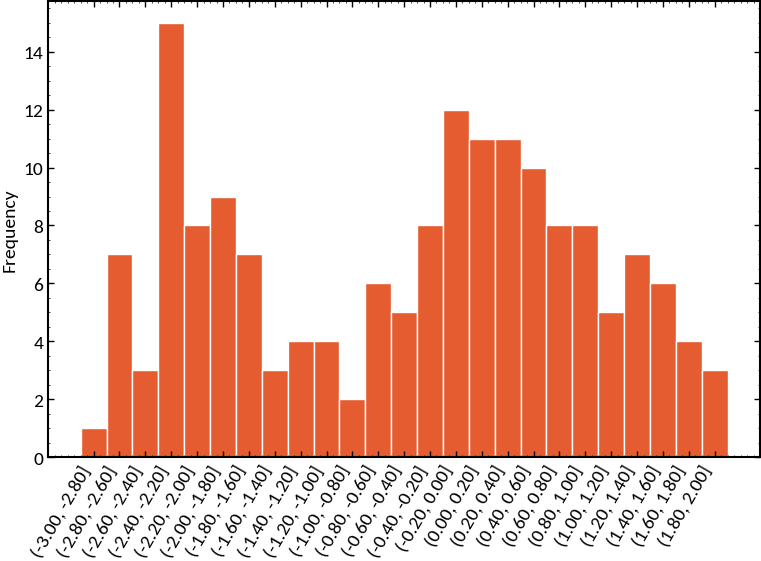

In [4]:
# Define custom bin edges
bins = np.arange(-3, 2.2, 0.2)

# Create the histogram
plt.figure(figsize=(8, 6))
plt.hist(data, bins=bins, color="#e55c30", edgecolor="white")

# X-axis ticks at bin centers with interval labels
bin_centers = (bins[:-1] + bins[1:]) / 2
labels = [f"({bins[i]:.2f}, {bins[i+1]:.2f}]" for i in range(len(bins) - 1)]

plt.xticks(bin_centers, labels, rotation=60, ha="right")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


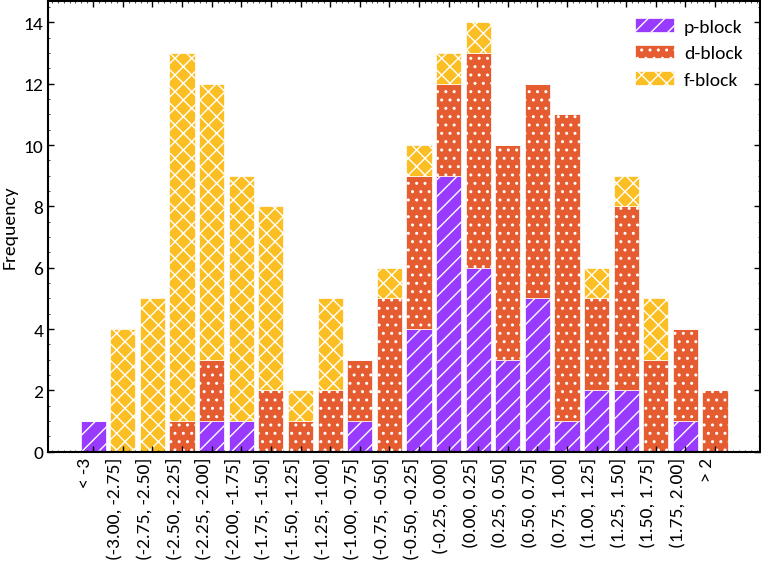

In [5]:
# 1. Setup Bins (27 total buckets)
bins = np.arange(-3, 2.25, 0.25)
df_var_srps["bin_idx"] = np.digitize(df_var_srps["SRP (V)"], bins, right=True)

# 2. Create a Cross-Tabulation (Counts of each Block per Bin)
# This creates a table where rows are bins and columns are s, p, d, f
composition = pd.crosstab(df_var_srps["bin_idx"], df_var_srps["Block"])

# Ensure all bins (0-26) and all blocks are represented, even if empty
all_indices = range(len(bins) + 1)
all_blocks = ["p", "d", "f"]
composition = composition.reindex(index=all_indices, columns=all_blocks, fill_value=0)

# 3. Plotting
plt.figure(figsize=(8, 6))
block_colors = {
    "p": "#993bff",  # Dark Purple
    "d": "#e55c30",  # Rust Red/Orange
    "f": "#fbbe23"   # Bright Yellow
}
bottoms = np.zeros(len(all_indices))

block_hatches = {"p": "//", "d": "..", "f": "xx"}

for block in all_blocks:
    plt.bar(
        all_indices, 
        composition[block], 
        bottom=bottoms, 
        color=block_colors[block],
        hatch=block_hatches[block],  # Apply the pattern here
        edgecolor="white",           # White edges help patterns pop
        linewidth=0.5,
        width=0.85, 
        label=f"{block}-block"
    )
    bottoms += composition[block]
    
labels = ["< -3"] + \
         [f"({bins[i]:.2f}, {bins[i+1]:.2f}]" for i in range(len(bins)-1)] + \
         ["> 2"]

plt.xticks(range(len(labels)), labels, rotation=90, ha="right")
plt.ylabel("Frequency")
plt.savefig('outputs/SRP_distribution.png', bbox_inches='tight')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()